TASK - 2 : Exploratory Data Analysis (EDA) & Business Intelligence

Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Loading

The dataset is loaded into a Pandas DataFrame for analysis.  
Initial inspection of the dataset helps understand its structure, including the number of rows and columns.

In [ ]:
# Load dataset
df = pd.read_csv("/content/online_retail.csv")
print("Shape:", df.shape)
df.head()

Shape: (82485, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


1: Descriptive Statistics & Univariate Analysis

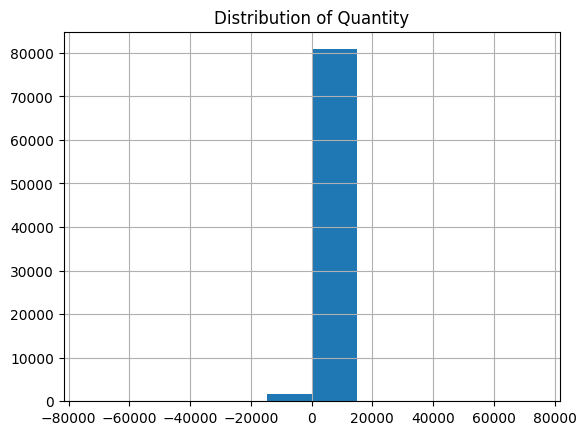

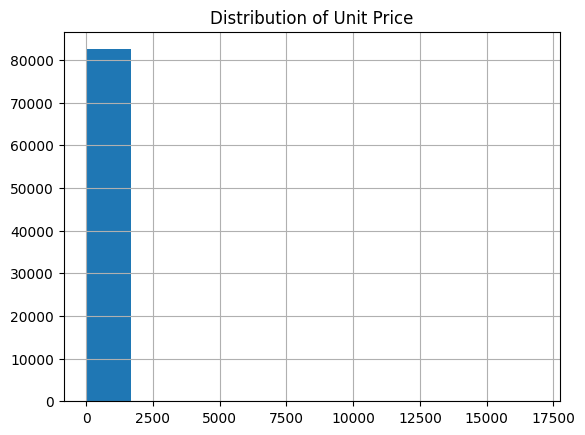

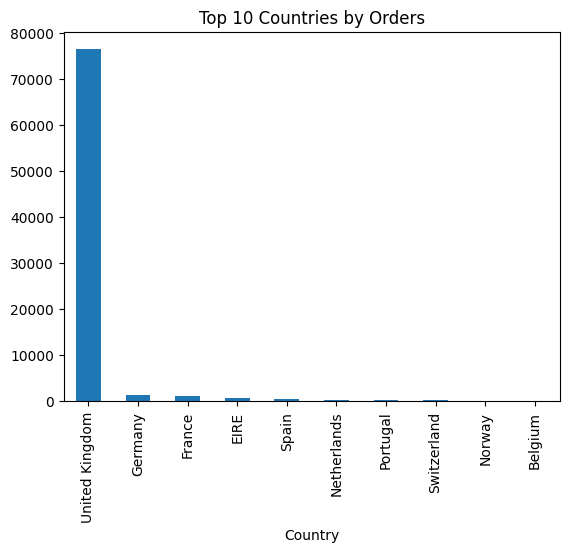

In [ ]:
# Summary statistics
df.describe()

# Categorical summary
df.describe(include='object')

# Histogram (Numerical)
import matplotlib.pyplot as plt

df['Quantity'].hist()
plt.title("Distribution of Quantity")
plt.show()

df['UnitPrice'].hist()
plt.title("Distribution of Unit Price")
plt.show()

# Bar chart (Categorical)
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Orders")
plt.show()

3: Multivariate Analysis & Correlation

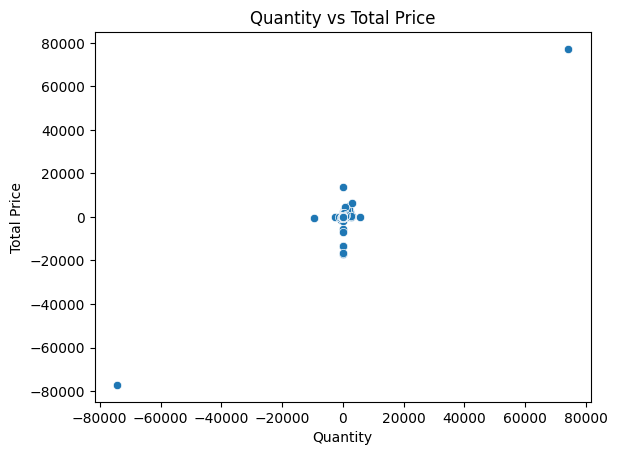

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Total Price
df['total_price'] = df['Quantity'] * df['UnitPrice']

# Quantity vs Total Price
sns.scatterplot(x='Quantity', y='total_price', data=df)
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

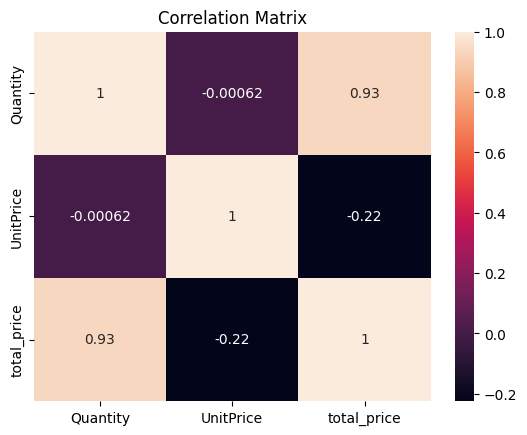

In [ ]:
# Select numerical columns
corr = df[['Quantity', 'UnitPrice', 'total_price']].corr()

# Plot heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

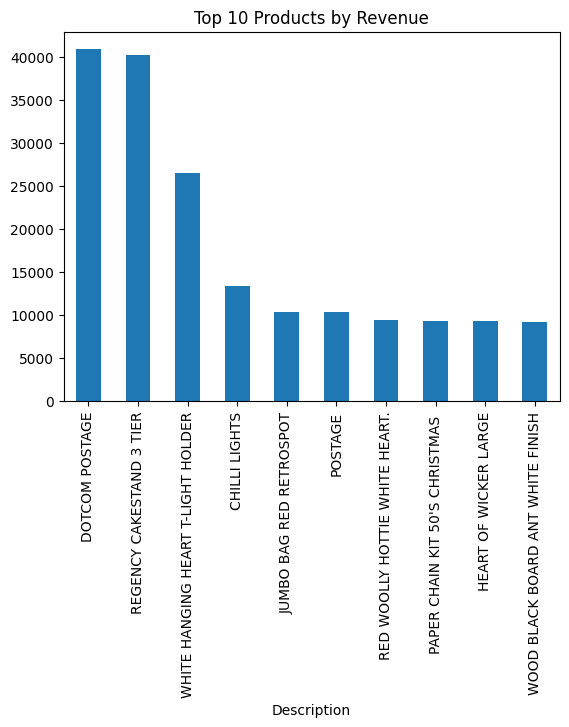

In [ ]:
# Top 10 products by revenue
top_products = df.groupby('Description')['total_price'].sum().nlargest(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()

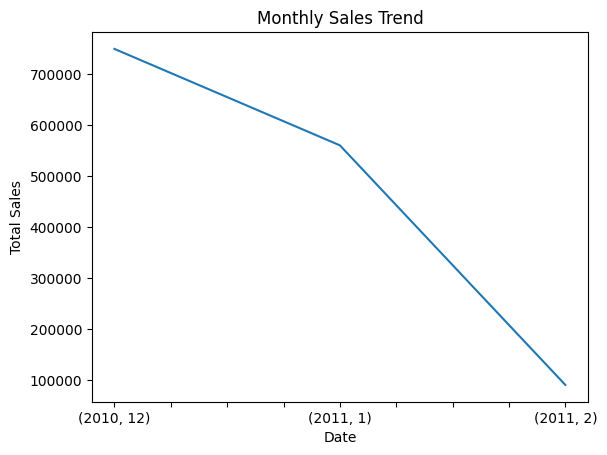

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['order_year'] = df['InvoiceDate'].dt.year
df['order_month'] = df['InvoiceDate'].dt.month

monthly_sales = df.groupby(['order_year', 'order_month'])['total_price'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()